Customer Churn Analysis – Project Overview

The dataset used in this project focuses on customer retention within the telecommunications industry. It contains various features related to customer behavior, subscription details, and usage patterns.

The main objective of this notebook is to perform an exploratory analysis of the dataset in order to better understand the key factors influencing customer churn.

1. Loading the dataset

This notebook begins by loading a CSV file using the Pandas library, followed by an initial exploration of the dataset, including a preview of the first rows and the column structure.

In [1]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. Understanding the dataset structure

df.info() reveals the data types and non-null counts for each column. TotalCharges appears as object (string) instead of float64, indicating it contains non-numeric values that need to be investigated.

In [2]:
df.info()
(df["TotalCharges"].str.strip() == "").sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

np.int64(11)

3. Investigating TotalCharges — type mismatch detected

df.info() revealed that TotalCharges is stored as a string instead of float64. Before converting it, we need to understand why. Which values are causing the issue and what they represent in the dataset.

In [3]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


4. Identifying non-numeric values in TotalCharges

In [4]:
print(df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]["TotalCharges"].unique())

<ArrowStringArray>
[' ']
Length: 1, dtype: str


&rarr; TotalCharges contains 11 rows with a single whitespace character ' ' instead of a numeric value. These correspond to new customers (tenure = 0) with no billing history yet. They will be converted to NaN using pd.to_numeric() then removed.

5.  Converting TotalCharges to numeric and removing missing values 

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.shape

(7032, 21)

7. Exploring the target variable : Visualizing the Churn distribution

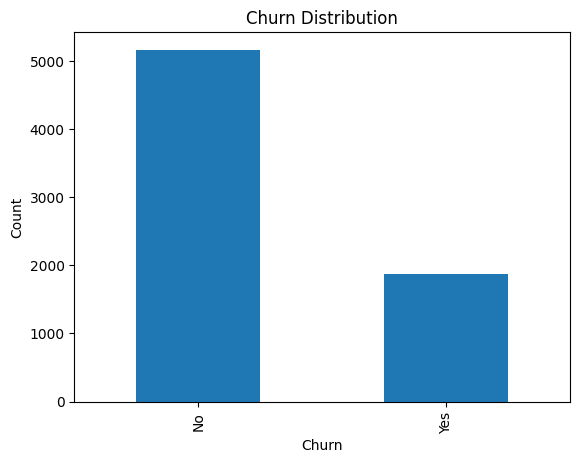

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

&rarr; The dataset is imbalanced, 73,5% No churn vs 26.5% Churn. Class imbalance will be handled using class_weight='balanced' during model training.

8.  Exploratory Data Analysis — feature correlation with Churn

We explore whether there is a correlation between MontlyCharges, Tenure, Contract, PaymentMethod, InternetService, SeniorCitizen, Dependents, TechSupport and churn rate.

Features selected for analysis:

- tenure — number of months the customer has been with the company
- MonthlyCharges — monthly amount charged to the customer
- Contract — contract type (Month-to-month / One year / Two year)
- PaymentMethod — payment method (Electronic check / Mailed check / Bank transfer / Credit card)
- InternetService — type of internet service (DSL / Fiber optic / No)
- SeniorCitizen — whether the customer is a senior (1 = Yes, 0 = No)
- Dependents — whether the customer has dependents (Yes / No)
- TechSupport — whether the customer has tech support (Yes / No)
- Churn — whether the customer churned (Yes / No) — target variable

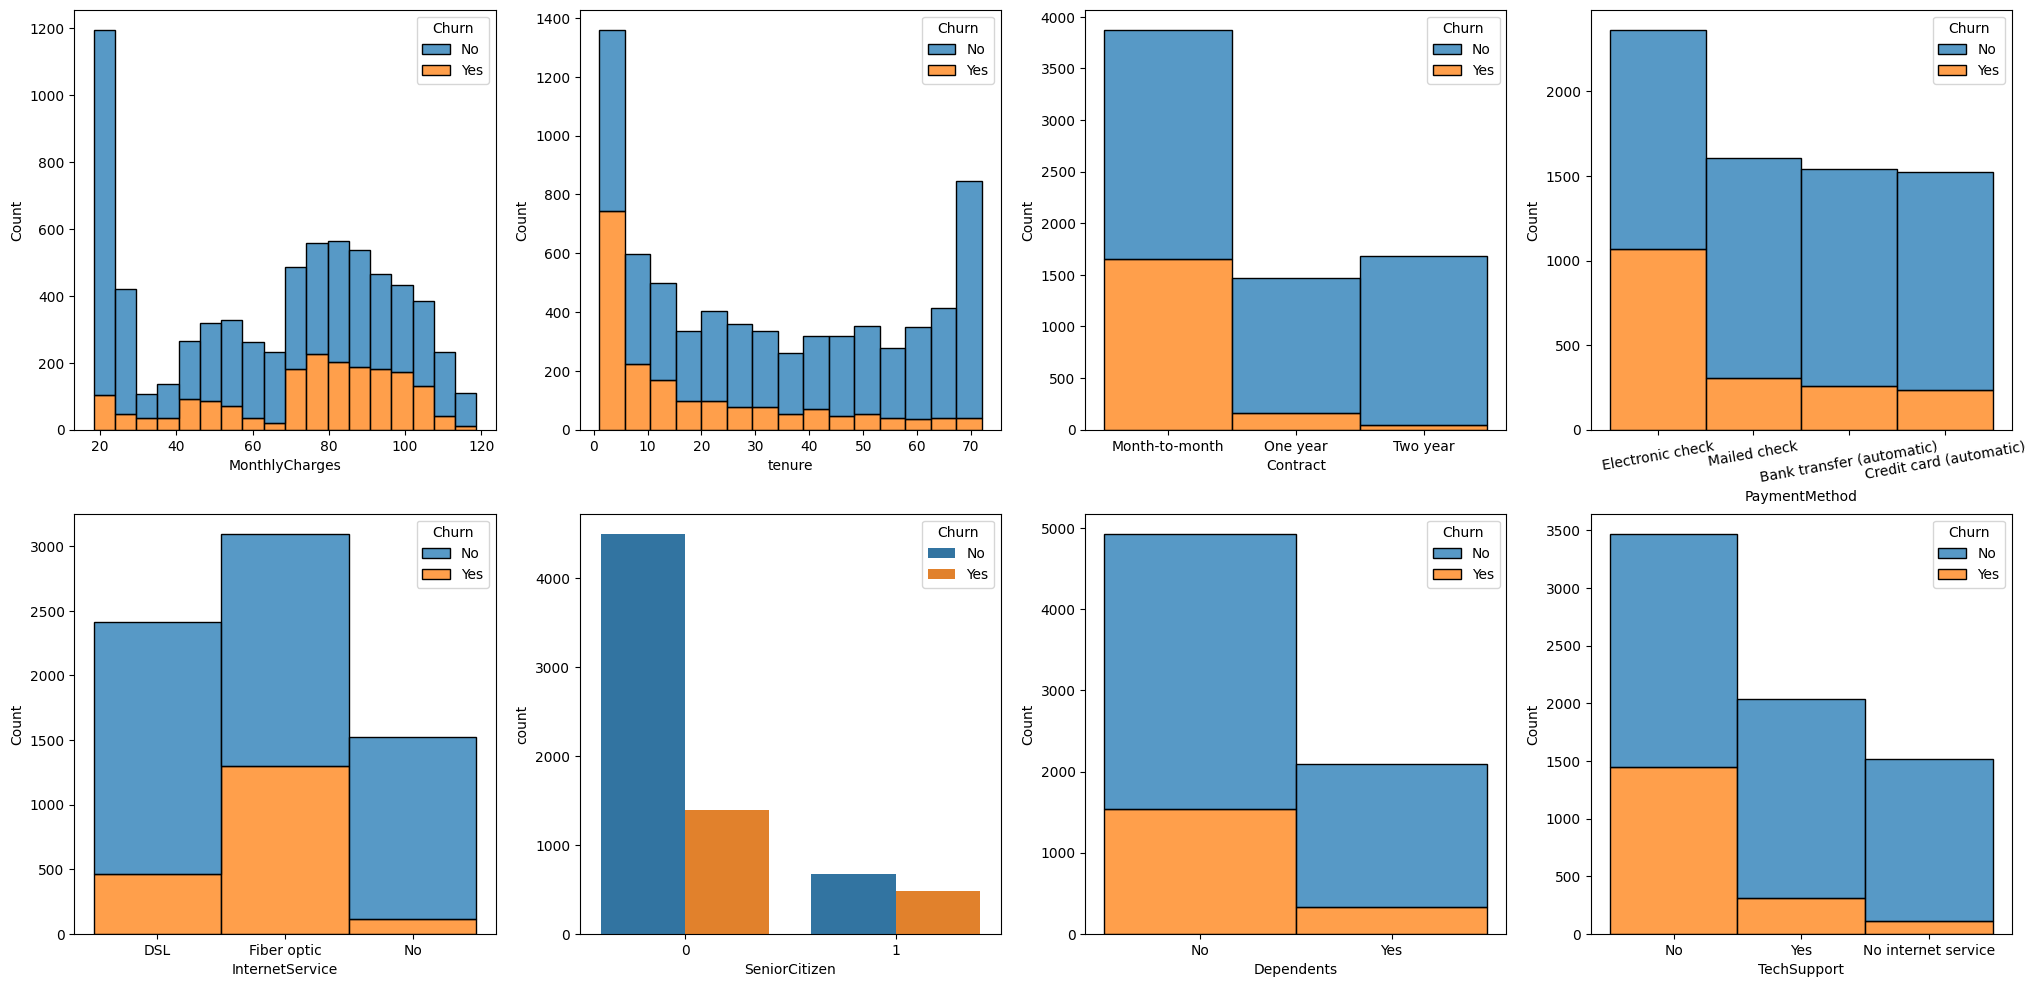

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(25, 12))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", ax=axes[0, 0])
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[0, 1])
sns.histplot(data=df, x="Contract", hue="Churn", multiple="stack", ax=axes[0, 2])
sns.histplot(data=df, x="PaymentMethod", hue="Churn", multiple="stack", ax=axes[0, 3])
axes[0, 3].tick_params(axis="x", labelsize=10, rotation=10)
sns.histplot(data=df, x="InternetService", hue="Churn", multiple="stack", ax=axes[1, 0])
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", ax=axes[1, 1])
sns.histplot(data=df, x="Dependents", hue="Churn", multiple="stack", ax=axes[1, 2])
sns.histplot(data=df, x="TechSupport", hue="Churn", multiple="stack", ax=axes[1, 3]);

&rarr; Key insights from the EDA:

- MonthlyCharges — customers with higher monthly charges tend to churn more. The higher the bill, the higher the risk of leaving.
- Tenure — new customers (low tenure) churn significantly more than long-term ones. The first months are the most critical.
- Contract — month-to-month customers churn far more than those on one or two-year contracts. Commitment reduces churn.
- PaymentMethod — customers paying by electronic check show a slightly higher churn rate compared to other methods.
- InternetService — fiber optic customers churn more, likely due to higher associated costs.
- SeniorCitizen — seniors (65+) churn proportionally more, possibly due to price sensitivity or lower digital engagement.
- Dependents — customers with dependents churn less. Managing multiple lines makes switching providers more complex.
- TechSupport — customers without tech support churn more. Lack of assistance when issues arise is a likely driver.

The following features were excluded after EDA: 
- gender — no significant difference in churn rate between male and female customers
- PhoneService — nearly all customers have phone service, no discriminating power
- MultipleLines — no meaningful correlation with churn observed
- OnlineSecurity — redundant with TechSupport for our prediction objective
- OnlineBackup — no significant correlation with churn
- DeviceProtection — no significant correlation with churn
- StreamingTV — usage of streaming services shows no clear churn pattern
- StreamingMovies — usage of streaming services shows no clear churn pattern
- PaperlessBilling — billing format not relevant to churn prediction
- customerID — unique identifier, not a predictive feature

These showed no significant correlation with churn or were irrelevant to the prediction objective.

9. Reducing the dataset to selected features

In [8]:
df_model = df[["MonthlyCharges", "tenure", "SeniorCitizen", "Dependents", "TechSupport", "Contract", "PaymentMethod", "InternetService", "Churn"]]


In [9]:
df_model.head()

,MonthlyCharges,tenure,SeniorCitizen,Dependents,TechSupport,Contract,PaymentMethod,InternetService,Churn
0,29.85,1,0,No,No,Month-to-month,Electronic check,DSL,No
1,56.95,34,0,No,No,One year,Mailed check,DSL,No
2,53.85,2,0,No,No,Month-to-month,Mailed check,DSL,Yes
3,42.30,45,0,No,Yes,One year,Bank transfer (automatic),DSL,No
4,70.70,2,0,No,No,Month-to-month,Electronic check,Fiber optic,Yes


10. Separating features and target — X and y

In [10]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

11. Splitting the dataset — train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

12. Preprocessing — encoding binary

In [12]:
y_train = y_train.map({"Yes": 1, "No": 0})
y_test = y_test.map({"Yes": 1, "No": 0})

for col in ["Dependents"]:
    X_train[col] = X_train[col].map({"Yes": 1, "No": 0})
    X_test[col] = X_test[col].map({"Yes": 1, "No": 0})

for col in ["TechSupport"]:    
    X_train[col] = X_train[col].map({"Yes": 1, "No": 0, "No internet service": 0 })
    X_test[col] = X_test[col].map({"Yes": 1, "No": 0, "No internet service": 0 })

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


13. One-hot encoding

In [14]:
X_train = pd.get_dummies(X_train, columns=["Contract", "PaymentMethod", "InternetService"])
X_test = pd.get_dummies(X_test, columns=["Contract", "PaymentMethod", "InternetService"])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

14. Model Training — Logistic Regression, Random Forest, XGBoost

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} trained - Accuracy: {model.score(X_test, y_test):.4f} | F1: {f1_score(y_test, y_pred):.4f} | Recall: {recall_score(y_test, y_pred):.4f}")


Logistic Regression trained - Accuracy: 0.7214 | F1: 0.5975 | Recall: 0.7781
Random Forest trained - Accuracy: 0.7569 | F1: 0.5100 | Recall: 0.4759
XGBoost trained - Accuracy: 0.7385 | F1: 0.5818 | Recall: 0.6845


&rarr; Model comparison — results interpretation

The three models were evaluated on accuracy, F1-score and recall. Given the class imbalance (73.5% No Churn vs 26.5% Churn), recall is the most critical metric — a missed churner means a lost customer with no retention action taken.

Logistic Regression achieves the best recall (0.78) and F1 (0.60), meaning it detects the most churners despite lower overall accuracy. Random Forest reaches the highest accuracy (75.69%) but misses nearly half of the churners (recall 0.48), making it less suitable for this use case. XGBoost offers a balanced trade-off between the two.

Conclusion: Logistic Regression is the most suitable model for churn detection, prioritizing churner identification over overall accuracy.

15. Hyperparameter tuning - GridSearchCV

In [23]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_iter": [100, 200, 500, 1000],
    "class_weight": ["balanced", None]
}

grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring="recall")
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(f"Best recall: {grid_search.best_score_:.4f}")

{'class_weight': 'balanced', 'max_iter': 100}
Best recall: 0.7940


In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "class_weight": ["balanced", None]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall")
grid_search_rf.fit(X_train, y_train)
print(grid_search_rf.best_params_)
print(f"Best recall: {grid_search_rf.best_score_:.4f}")

In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6, 10],
    "scale_pos_weight": [(y_train == 0).sum() / (y_train == 1).sum(), 1]
}

grid_search_xgb = GridSearchCV(XGBClassifier(eval_metric="logloss", random_state=42), param_grid_xgb, cv=5, scoring="recall")
grid_search_xgb.fit(X_train, y_train)
print(grid_search_xgb.best_params_)
print(f"Best recall: {grid_search_xgb.best_score_:.4f}")